# Week 1: Strategic Planning and Data Exploration in Logistics

## 1. Project Definition

## 2. Project Objective

## 3. Dataset Loading and Initial Inspection

## 4. Data Cleaning and Validation

## 5. Delivery Performance Analysis

## 6. Key Performance Indicators (KPIs)

## 7. Exploratory Data Analysis and Visualization

## 8. Strategic Roadmap

## 9. Data Science Methodologies

## 10. Proposed Predictive Analysis

## 11. Literature and Data Research

## 12. Expected Outcomes

## 13. Conclusion

In [1]:
import pandas as pd
print("pandas version :", pd.__version__)
print("pandas environment is ready......")

pandas version : 2.2.3
pandas environment is ready......


In [2]:
import pandas as pd

orders = pd.read_csv("/content/df_Orders.csv")

print("Dataset loaded successfully!")
print("Rows:", orders.shape[0])
print("Columns:", orders.shape[1])
orders.head()
orders.columns
orders.info()

Dataset loaded successfully!
Rows: 89316
Columns: 7
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       89316 non-null  object
 1   customer_id                    89316 non-null  object
 2   order_status                   89316 non-null  object
 3   order_purchase_timestamp       89316 non-null  object
 4   order_approved_at              89307 non-null  object
 5   order_delivered_timestamp      87427 non-null  object
 6   order_estimated_delivery_date  89316 non-null  object
dtypes: object(7)
memory usage: 4.8+ MB


In [3]:
missing_values=orders.isnull().sum()
print("missing values in each column :")
print(missing_values)
missing_persentage=(orders.isnull().sum()/len(orders))*100
print("missing persentage in each column :")
print(missing_persentage.round(2))
print("orders status")
print(orders["order_status"].value_counts())
print("duplicate rows:", orders.duplicated().sum())
date_format=["order_purchase_timestamp","order_approved_at","order_delivered_timestamp","order_estimated_delivery_date"]
for column in date_format:
  orders[column]=pd.to_datetime(orders[column],errors="coerce")
orders.info()





missing values in each column :
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   9
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64
missing persentage in each column :
order_id                         0.00
customer_id                      0.00
order_status                     0.00
order_purchase_timestamp         0.00
order_approved_at                0.01
order_delivered_timestamp        2.11
order_estimated_delivery_date    0.00
dtype: float64
orders status
order_status
delivered      87428
shipped          936
canceled         409
processing       273
invoiced         266
unavailable        2
approved           2
Name: count, dtype: int64
duplicate rows: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89316 entries, 0 to 89315
Data columns (total 7 columns):
 #   Column                         Non-Null C

In [4]:
orders["delivery_days"]=(orders["order_delivered_timestamp"]-orders["order_purchase_timestamp"]).dt.days
orders[["order_purchase_timestamp","order_delivered_timestamp","delivery_days"]].head()
orders["delivery_days"].describe()
print((orders["delivery_days"]<0).sum())
print((orders["delivery_days"]>100).sum())
orders.loc[orders["delivery_days"]>100,["order_id","order_status","order_purchase_timestamp","order_delivered_timestamp","delivery_days"]].sort_values(by="delivery_days",ascending=False).head(10)
print(orders[date_format].isnull().sum())
print(orders["order_status"].value_counts())
orders["delivery_days"].describe()


0
43
order_purchase_timestamp            0
order_approved_at                   9
order_delivered_timestamp        1889
order_estimated_delivery_date       0
dtype: int64
order_status
delivered      87428
shipped          936
canceled         409
processing       273
invoiced         266
unavailable        2
approved           2
Name: count, dtype: int64


,delivery_days
count,87427.000000
mean,11.969129
std,9.277678
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [5]:
average_delivery=orders["delivery_days"].mean()
print("average delivery days is :",round(average_delivery,2))
median_delivery=orders["delivery_days"].median()
print("median delivery days is :",round(median_delivery,2))
delivered_orders = orders[
    (orders["order_status"] == "delivered") &
    (orders["order_delivered_timestamp"].notna())
].copy()

delivered_orders["on_time"] = (
    delivered_orders["order_delivered_timestamp"]
    <= delivered_orders["order_estimated_delivery_date"]
)

print(delivered_orders["on_time"].value_counts())
on_time_rate=delivered_orders["on_time"].mean()*100
late_rate=100-on_time_rate
print("on time rate is :",round(on_time_rate,2),"%")
print("late rate is :",round(late_rate,2),"%")


average delivery days is : 11.97
median delivery days is : 10.0
on_time
True     80685
False     6737
Name: count, dtype: int64
on time rate is : 92.29 %
late rate is : 7.71 %


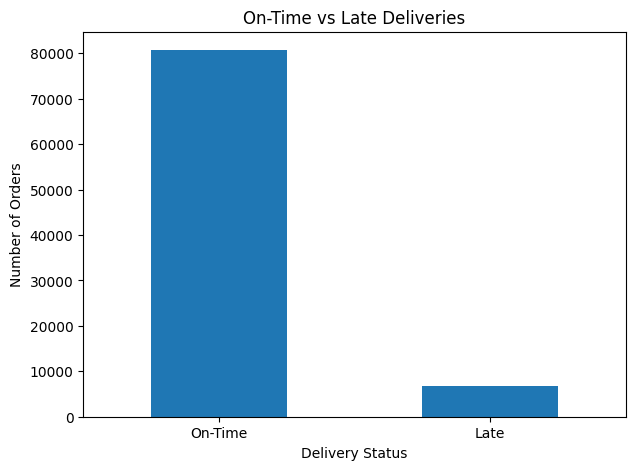

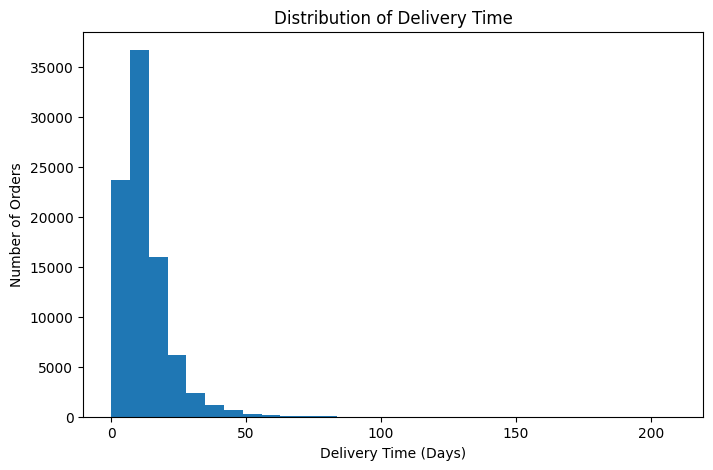

In [6]:
import matplotlib.pyplot as plt

delivery_status = delivered_orders["on_time"].value_counts()

plt.figure(figsize=(7, 5))
delivery_status.plot(kind="bar")

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Orders")

plt.xticks(
    [0, 1],
    ["On-Time", "Late"],
    rotation=0
)

plt.show()
plt.figure(figsize=(8, 5))

plt.hist(
    delivered_orders["order_delivered_timestamp"]
    .sub(delivered_orders["order_purchase_timestamp"])
    .dt.days,
    bins=30
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.show()

## Project Scenario

This project focuses on analyzing e-commerce logistics delivery performance.
An e-commerce company receives thousands of customer orders that must be
processed, shipped, and delivered within the estimated delivery period.

The company wants to understand its delivery performance, identify delayed
orders, measure important logistics KPIs, and develop data-driven strategies
for improving delivery efficiency.

Historical order data is analyzed using Python to calculate delivery time,
on-time delivery rate, late delivery rate, and other performance indicators.

The analysis can help logistics managers identify delivery problems,
prioritize delayed orders, improve resource allocation, and support future
predictive and optimization-based decision-making.

## Strategic Roadmap

1. Data Collection
   ↓
2. Data Cleaning and Validation
   ↓
3. Exploratory Data Analysis
   ↓
4. KPI Calculation
   ↓
5. Feature Engineering
   ↓
6. Predictive Modeling
   ↓
7. Customer/Order Segmentation
   ↓
8. Logistics Optimization
   ↓
9. Model Evaluation
   ↓
10. Business Recommendations

## Data Science Methodologies for Logistics

### 1. Regression

Regression can be used to predict delivery time based on factors such as
order characteristics, product information, customer location, and
historical delivery performance.

For example, a regression model could predict the expected number of
days required to deliver a new order.

Input Features
      ↓
Regression Model
      ↓
Predicted Delivery Time

Business Benefit:
The company can identify orders that are likely to take longer than
expected and take preventive action.

### 2. Clustering

Clustering can be used to group orders or customers with similar
logistics characteristics.

For example, customers could be grouped based on order frequency,
average delivery time, and delivery behavior.

Customer/Order Data
      ↓
Clustering Algorithm
      ↓
Similar Groups

Business Benefit:
The logistics team can identify high-volume customers, slow-delivery
groups, or other segments that require special attention.

### 3. Optimization

Optimization techniques can help logistics companies make better
decisions about routes, vehicles, warehouses, and delivery schedules.

For example, route optimization can consider:

- Delivery locations
- Vehicle capacity
- Delivery time
- Distance
- Number of orders

Input: Orders + Locations + Vehicle Constraints
                     ↓
              Optimization
                     ↓
            Efficient Routes

Business Benefit:
Optimization can reduce transportation costs, delivery time, and
unnecessary resource usage.

## Proposed Predictive Analysis

The future predictive model will use historical logistics data to predict
delivery performance.

Example workflow:

Load historical data
        ↓
Clean the data
        ↓
Create relevant features
        ↓
Split data into training and testing sets
        ↓
Train regression model
        ↓
Predict delivery time
        ↓
Evaluate model performance
        ↓
Use predictions for logistics planning

In [7]:
# Illustrative predictive modeling workflow

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Example features and target
# X = logistics-related features
# y = delivery time

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# model = LinearRegression()
# model.fit(X_train, y_train)

# predictions = model.predict(X_test)

## 11. Literature and Data Research

### Dataset Research

This project uses the Brazilian E-Commerce Public Dataset by Olist,
which is a publicly available e-commerce dataset containing approximately
100,000 orders from 2016 to 2018.

The dataset contains information related to order status, purchase
timestamps, delivery timestamps, estimated delivery dates, customer
locations, products, payments, freight and reviews.

For this Week 1 project, the orders dataset is used to analyze delivery
performance and calculate logistics KPIs.

### Relevance to Logistics Analytics

Delivery performance is an important part of e-commerce logistics because
late deliveries can affect customer satisfaction, operational efficiency,
and resource planning.

The Olist dataset is particularly suitable for this project because it
contains both actual delivery dates and estimated delivery dates. This
allows the analysis to measure delivery duration and determine whether an
order was delivered on time.

### Application of Data Science

Regression can be used to predict delivery time or identify orders that
may experience delays.

Clustering can be used to group customers or orders with similar
characteristics, such as delivery behavior, order frequency, or delivery
duration.

Optimization techniques can be used to improve decisions involving
delivery routes, vehicle capacity, delivery schedules, and resource
allocation.

Recent supply-chain research also demonstrates the use of predictive
analytics and clustering for delivery-risk analysis and customer
segmentation, supporting the use of data-driven approaches in logistics.

### Research-Based Strategic Approach

Based on the dataset and the reviewed research, this project follows a
data-driven approach:

Data Collection
      ↓
Data Cleaning
      ↓
Exploratory Analysis
      ↓
KPI Measurement
      ↓
Predictive Analysis
      ↓
Segmentation
      ↓
Optimization
      ↓
Business Recommendations

### References

1. Olist. Brazilian E-Commerce Public Dataset by Olist. Kaggle.
   Public dataset containing e-commerce order, customer, product,
   payment, freight and review information.

2. Supply Chain Analytics (2026). An empirical analysis of data-driven
   supply chain optimization in retail and logistics. ScienceDirect.

3. Supply Chain Analytics (2023). A hybrid forecasting model with
   logistic regression and neural networks for improving key performance
   indicators in supply chains.

## 12. Expected Outcomes

### Expected Delivery Performance Insights

The analysis is expected to provide a clear understanding of e-commerce delivery performance by measuring delivery duration and comparing actual delivery dates with estimated delivery dates. The analysis can help identify normal delivery patterns, delayed orders, and unusual delivery durations.

### Expected KPI Insights

The project is expected to provide important logistics KPIs, including average delivery time, median delivery time, on-time delivery rate, and late delivery rate. These KPIs can be used to evaluate the reliability and efficiency of the delivery process.

### Expected Business Insights

The analysis can help identify potential delivery inefficiencies and areas requiring operational attention. Orders with long delivery durations or late deliveries can be investigated to understand possible causes and improve logistics planning.

### Expected Data Science Applications

The project demonstrates how regression, clustering, and optimization can be applied to logistics. Regression can support delivery-time prediction, clustering can identify groups of customers or orders with similar characteristics, and optimization can support better routing, scheduling, and resource allocation.

### Expected Strategic Impact

The expected outcome is a data-driven approach to logistics decision-making. The insights from the analysis can help logistics managers monitor delivery performance, identify potential delays, allocate resources more effectively, and develop strategies for improving customer service and operational efficiency.

## 13. Conclusion

This Week 1 project developed a strategic approach for analyzing e-commerce logistics delivery performance using Python and the Brazilian E-Commerce Public Dataset by Olist. The analysis focused on understanding delivery duration, identifying delivery performance patterns, and calculating important logistics KPIs.

The analysis showed an average delivery time of approximately 11.97 days and a median delivery time of 10 days. Among the delivered orders with valid delivery information, approximately 92.29% were delivered on time, while 7.71% were delivered late. These results demonstrate how logistics KPIs can be used to evaluate delivery reliability and identify areas for operational improvement.

The project also established a strategic roadmap covering data collection, data cleaning, exploratory analysis, KPI measurement, feature engineering, predictive modeling, segmentation, optimization, and business recommendations. Regression, clustering, and optimization were identified as useful data science techniques for future logistics analysis.

Overall, this project demonstrates how Python and data science can support logistics decision-making. Future analysis can extend the project by developing predictive models for delivery delays, identifying high-risk orders, segmenting customers or orders, and optimizing logistics resources. These approaches can help organizations improve delivery efficiency, reduce delays, optimize resources, and enhance customer satisfaction.